<a href="https://colab.research.google.com/github/aannddrree/disciplinaIA/blob/main/Q_Learning_GridWorld_Didatico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizado por Reforço — Q-Learning
## Experimento didático em GridWorld

Este notebook acompanha o material de aula e implementa o experimento descrito nos slides:

- **35 estados** (grade 5 × 7)
- **4 ações**: cima, direita, baixo e esquerda
- **α = 0,20**
- **γ = 0,95**
- **ε decresce de 1,00 para 0,05**
- **1.500 episódios de treinamento**
- **máximo de 100 passos por episódio**
- somente **NumPy e Matplotlib**

O objetivo é mostrar, passo a passo, como um agente aprende por tentativa e erro usando Q-Learning.


## 1. Ideia central

Em cada passo, o agente:

1. observa o estado atual `s`;
2. escolhe uma ação `a`;
3. recebe uma recompensa `r` e chega ao estado `s'`;
4. atualiza a tabela Q.

A atualização utilizada é:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'}Q(s',a') - Q(s,a)]
\]

Quando `s'` é terminal, o valor futuro é **zero**.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# Hiperparâmetros do slide
ALPHA = 0.20
GAMMA = 0.95
EPSILON_INICIAL = 1.00
EPSILON_FINAL = 0.05
EPISODIOS = 1500
MAX_PASSOS = 100

LINHAS = 5
COLUNAS = 7
N_ESTADOS = LINHAS * COLUNAS
N_ACOES = 4

# 0=cima, 1=direita, 2=baixo, 3=esquerda
ACOES = [(-1, 0), (0, 1), (1, 0), (0, -1)]
SIMBOLOS = ["↑", "→", "↓", "←"]

INICIO = (4, 0)
OBJETIVO = (0, 6)
PERIGO = (3, 5)

print("Estados:", N_ESTADOS)
print("Ações:", N_ACOES)


Estados: 35
Ações: 4


## 2. Ambiente

A posição do agente é o **estado**. Ao tentar sair da grade, ele permanece na mesma célula.

Recompensas utilizadas, conforme o material:

- objetivo: **+1**
- perigo: **−1**
- cada passo: **−0,04**

O episódio termina ao chegar ao objetivo, ao perigo ou ao atingir o limite de passos.


In [4]:
def estado_id(pos):
    linha, coluna = pos
    return linha * COLUNAS + coluna

def id_pos(estado):
    return divmod(estado, COLUNAS)

def reset():
    return estado_id(INICIO)

def step(estado, acao):
    linha, coluna = id_pos(estado)
    dl, dc = ACOES[acao]

    nl = np.clip(linha + dl, 0, LINHAS - 1)
    nc = np.clip(coluna + dc, 0, COLUNAS - 1)
    nova_pos = (int(nl), int(nc))

    if nova_pos == OBJETIVO:
        return estado_id(nova_pos), 1.0, True

    if nova_pos == PERIGO:
        return estado_id(nova_pos), -1.0, True

    return estado_id(nova_pos), -0.04, False


## 3. Política ε-gulosa

Durante o treinamento precisamos equilibrar:

- **exploração**: experimentar uma ação aleatória;
- **aproveitamento**: escolher a melhor ação conhecida.

Com probabilidade `ε`, exploramos. Caso contrário, escolhemos uma ação de maior valor Q.

Nos empates entre ações de mesmo valor, a escolha é aleatória.


In [5]:
def epsilon_gulosa(Q, estado, epsilon):
    if rng.random() < epsilon:
        return rng.integers(N_ACOES)

    valores = Q[estado]
    melhores = np.flatnonzero(valores == valores.max())
    return rng.choice(melhores)

def epsilon_do_episodio(ep):
    # Decaimento linear de 1,00 até 0,05
    fracao = ep / (EPISODIOS - 1)
    return EPSILON_INICIAL + fracao * (EPSILON_FINAL - EPSILON_INICIAL)


## 4. Treinamento do Q-Learning

Observe especialmente estas linhas:

```python
futuro = 0 if terminou else np.max(Q[proximo])
alvo = recompensa + GAMMA * futuro
Q[estado, acao] += ALPHA * (alvo - Q[estado, acao])
```

Elas correspondem diretamente à equação do Q-Learning apresentada em aula.


In [6]:
Q = np.zeros((N_ESTADOS, N_ACOES))

retornos = []
passos_por_episodio = []
sucessos = []

for episodio in range(EPISODIOS):
    estado = reset()
    epsilon = epsilon_do_episodio(episodio)
    retorno = 0.0
    sucesso = False

    for passo in range(1, MAX_PASSOS + 1):
        acao = epsilon_gulosa(Q, estado, epsilon)
        proximo, recompensa, terminou = step(estado, acao)

        futuro = 0.0 if terminou else np.max(Q[proximo])
        alvo = recompensa + GAMMA * futuro

        Q[estado, acao] += ALPHA * (alvo - Q[estado, acao])

        retorno += recompensa
        estado = proximo

        if terminou:
            sucesso = id_pos(estado) == OBJETIVO
            break

    retornos.append(retorno)
    passos_por_episodio.append(passo)
    sucessos.append(sucesso)

print("Treinamento concluído.")
print(f"Sucesso nos últimos 100 episódios: {np.mean(sucessos[-100:])*100:.1f}%")
print(f"Passos médios nos últimos 100 episódios: {np.mean(passos_por_episodio[-100:]):.1f}")


Treinamento concluído.
Sucesso nos últimos 100 episódios: 100.0%
Passos médios nos últimos 100 episódios: 10.8


## 5. Evolução do treinamento

Os gráficos permitem observar se o agente passa a obter melhores retornos e chegar ao objetivo com menos passos.


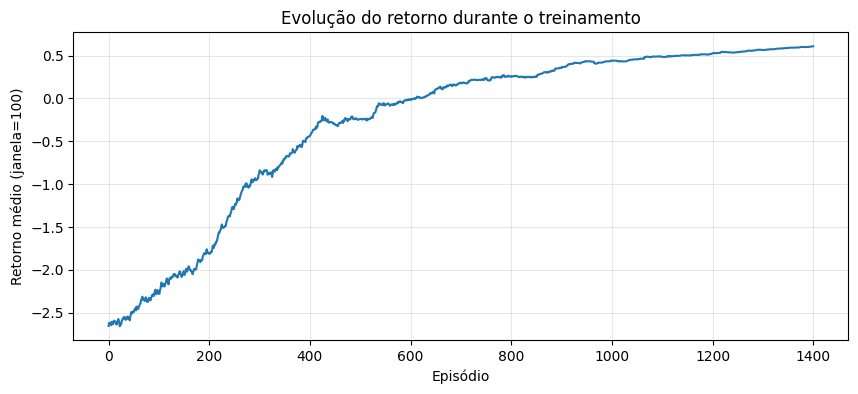

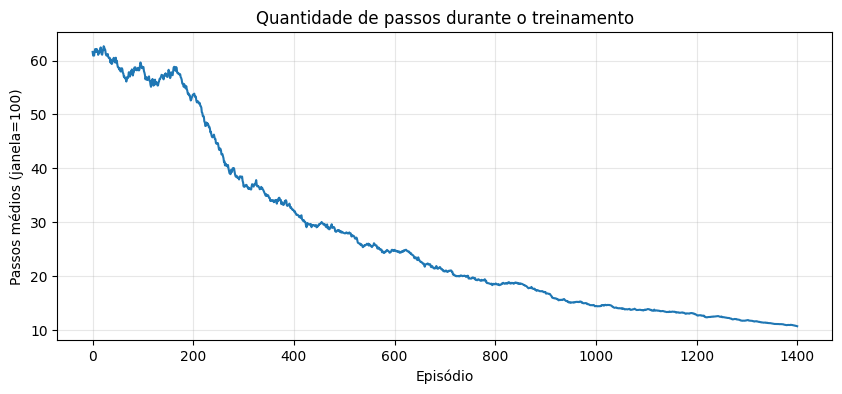

In [7]:
janela = 100

def media_movel(valores, janela):
    valores = np.asarray(valores, dtype=float)
    return np.convolve(valores, np.ones(janela)/janela, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(media_movel(retornos, janela))
plt.xlabel("Episódio")
plt.ylabel("Retorno médio (janela=100)")
plt.title("Evolução do retorno durante o treinamento")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(media_movel(passos_por_episodio, janela))
plt.xlabel("Episódio")
plt.ylabel("Passos médios (janela=100)")
plt.title("Quantidade de passos durante o treinamento")
plt.grid(alpha=0.3)
plt.show()


## 6. Política aprendida

Depois do treinamento, podemos visualizar qual ação possui o maior Q em cada estado.


In [8]:
politica = np.argmax(Q, axis=1)

for l in range(LINHAS):
    linha = []
    for c in range(COLUNAS):
        pos = (l, c)
        if pos == OBJETIVO:
            linha.append(" G ")
        elif pos == PERIGO:
            linha.append(" X ")
        elif pos == INICIO:
            linha.append(" S ")
        else:
            linha.append(f" {SIMBOLOS[politica[estado_id(pos)]]} ")
    print("".join(linha))


 →  →  →  →  →  →  G 
 →  ↑  ↑  ↑  ↑  ↑  ↑ 
 ↑  ↑  ↑  ↑  ↑  ↑  ↑ 
 ↑  ↑  ↑  ↑  ↑  X  ↑ 
 S  ↑  ↑  ↑  ↑  ←  ↑ 


## 7. Avaliação — treinamento ≠ teste

Na avaliação usamos **ε = 0** e **não atualizamos Q**.

Isso é importante: queremos medir a política que foi aprendida, e não continuar ensinando o agente durante o teste.


In [9]:
def avaliar(Q, episodios=300):
    sucessos_teste = 0
    retornos_teste = []
    passos_teste = []

    for _ in range(episodios):
        estado = reset()
        retorno = 0.0

        for passo in range(1, MAX_PASSOS + 1):
            valores = Q[estado]
            melhores = np.flatnonzero(valores == valores.max())
            acao = rng.choice(melhores)

            proximo, recompensa, terminou = step(estado, acao)
            retorno += recompensa
            estado = proximo

            if terminou:
                if id_pos(estado) == OBJETIVO:
                    sucessos_teste += 1
                break

        retornos_teste.append(retorno)
        passos_teste.append(passo)

    return {
        "sucesso": sucessos_teste / episodios,
        "retorno_medio": np.mean(retornos_teste),
        "passos_medios": np.mean(passos_teste),
    }

resultado = avaliar(Q)

print("RESULTADO DO TESTE")
print(f"Taxa de sucesso: {resultado['sucesso']*100:.1f}%")
print(f"Retorno médio: {resultado['retorno_medio']:.2f}")
print(f"Passos médios: {resultado['passos_medios']:.1f}")


RESULTADO DO TESTE
Taxa de sucesso: 100.0%
Retorno médio: 0.64
Passos médios: 10.0


## 8. Exercícios para os alunos

Agora altere **uma hipótese por vez** e explique o efeito observado.

Sugestões:

1. O que acontece se `γ` cair de `0.95` para `0.20`?
2. O que acontece se `α` passar de `0.20` para `0.90`?
3. O que acontece se `ε` permanecer sempre em `1.0`?
4. Aumente a penalidade por passo. O caminho aprendido muda?
5. Mude a posição do perigo e treine novamente.

### Pergunta final

> O agente realmente “sabe” qual é o caminho correto ou aprendeu valores para as consequências de suas ações?

Use os resultados do experimento para justificar sua resposta.
